# (노트) 클래스2022(5)

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- categories: [파이썬]

In [345]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## 클래스공부 7단계

### 함수공부 

`-` 다시 함수를 공부해봅시다. 

In [13]:
def f(x):
    return x+1

In [14]:
f(3)

4

`-` 함수의 사용방법? 
- 입력으로 변수 x를 받음 = 입력으로 인스턴스 x를 받음
- 출력으로 변수 x+1을 리턴 = 출력으로 인스턴스 x+1을 리턴 

`-` 사실1: 파이썬에서 함수는 인스턴스를 입력으로 받고 인스턴스를 출력한다. 

`-` 함수의 자료형? 

In [15]:
?f

Signature: f(x)
Docstring: <no docstring>
File:      /tmp/ipykernel_2443970/1304018138.py
Type:      function


- type이 function이다.
- f는 function class의 instance이다? 
- 결국 f 역시 하나의 오브젝트에 불과하다. 

`-` 사실2: 함수도 결국 인스턴스이다. $\to$ 함수의 입력으로 함수를 쓸 수도 있고 함수의 출력으로 함수가 나올 수도 있다. 

### 함수형 프로그래밍

(예제1) 숫자입력, 함수출력 

In [46]:
def f(a):
    def _f(x):
        return (x-a)**2
    return _f

In [47]:
g=f(10) # g(x) = (x-10)^2 이 된다. 

In [48]:
g(2) 

64

- 해석: f(a)는 a를 입력으로 받고 g(x)=(x-a)^2 를 리턴해주는 함수 

(예제2) 예제1의 다른 표현 (익명함수)

In [55]:
def f(a):
    _f = lambda x: (x-a)**2 ## lambda x: (x-a)**2 가 실행되는 순간 함수오브젝트가 만들어지고 그게 _f 로 저장됨 
    return _f

In [56]:
g=f(10)

In [57]:
g(2)

64

In [58]:
def f(a):
    return lambda x: (x-a)**2 

In [59]:
g=f(10)

In [60]:
g(2)

64

- lambda x: (x-a)**2 는 $lambda(x)=(x-a)^2$ 의 느낌으로 기억하면 쉽다. 
- lambda x: (x-a)**2 는 "아직 이름이 없는 함수오브젝트를 (가칭 lambda 라고 하자) 만들고 그 기능은 x를 입력으로 하고 (x-a)**2를 출력으로 하는 함수로 정의하자" 라는 뜻으로 해서하면 된다.  

(예제2) 함수입력, 숫자출력 

In [61]:
def f(x): 
    return x**2 

In [24]:
def d(f,x): # 함수를 입력으로 받는 함수 
    h=0.00000001
    return (f(x+h)-f(x))/h

In [25]:
d(f,4) 

7.999999951380232

(예제3) 함수입력, 함수출력 

In [86]:
def f(x):
    return x**2 

In [87]:
def derivate(f):
    def df(x):
        h=0.00000001
        return (f(x+h)-f(x))/h
    return df

In [88]:
ff = derivate(f)

In [89]:
ff(10)

20.00000165480742

**원래함수 시각화**

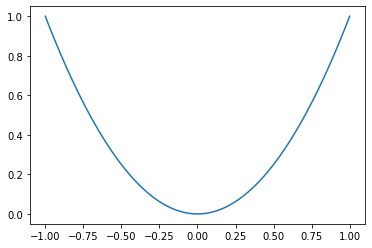

In [91]:
x=np.linspace(-1,1,100)
plt.plot(x,f(x))

**도함수 시각화**

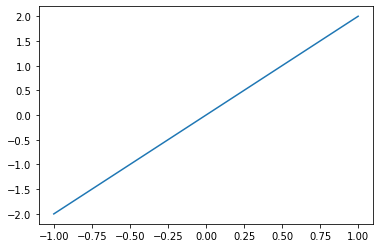

In [92]:
x=np.linspace(-1,1,100)
plt.plot(x,ff(x))

(예제3)의 다른 표현 

In [93]:
def f(x):
    return x**2 

In [94]:
def derivate(f):
    h=0.00000001
    return lambda x: (f(x+h)-f(x))/h

In [95]:
ff = derivate(f)

In [96]:
ff(10)

20.00000165480742

(예제4) 함수들의 리스트

In [122]:
fs = [lambda x: x, lambda x: x**2, lambda x: x**3] 

In [123]:
for f in fs: 
    print(f(2))

2
4
8


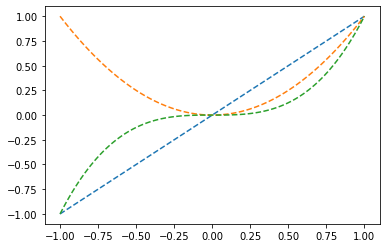

In [124]:
for f in fs: 
    plt.plot(x,f(x),'--')

### 정리 

`-` 지금까지 개념 
- 함수: 변수를 입력으로 받아서 변수를 출력하는 개념
- 변수: 어떠한 값을 저장하는 용도로 쓰거나 함수의 입력 혹은 출력을 사용함 

`-` 객체지향적 언어의 특징 
- 변수든 함수든 일단 둘다 인스턴스임. 
- 변수를 함수처럼: 메소드
- 함수를 변수처럼: 함수자체를 함수의 입력으로 혹은 출력으로 쓰기도 한다. 함수를 값처럼 생각하여 함수들의 list를 만들수도 있다. 

### callable object

`-` 함수 오브젝트의 비밀?

In [125]:
f = lambda x: x+1 

In [130]:
set(dir(f)) & {'__call__'}

{'__call__'}

- 함수 오브젝트에는 숨겨진 메소드 `__call__` 이 있다. 

In [132]:
f.__call__(3)

4

In [133]:
f.__call__(4)

5

- 여기에 우리가 정의한 내용이 있었다. 

`-` 함수처럼 쓸 수 없는 인스턴스는 단지 call이 없는 것일뿐!

In [151]:
class Klass:
    def __init__(self):
        self.name='guebin'

In [152]:
a=Klass()

In [153]:
a()

TypeError: 'Klass' object is not callable

- a는 callable이 아니라고 한다. 

In [154]:
class Klass2(Klass): # 상속.. 
    def __call__(self):
        print(self.name)

In [155]:
b=Klass2()

In [156]:
b()

guebin


- b는 callable object! 즉 숨겨진 메소드로 `__call__`을 가진 오브젝트!
- Klass는 callable object를 만들지 못하지만 Klass2는 callable object를 만든다. 

`-` 클래스로 함수 만들기?

In [161]:
class AddConstant:
    def __init__(self,c):
        self.c = c 
    def __call__(self,a):
        return a + self.c 

In [162]:
f=AddConstant(3)

In [163]:
f(5)

8

In [164]:
f(10)

13

`-` 클래스도 그러보니까 `오브젝트`아니었나? 그리고 클래스도 함수처럼 `Klass()`와 같이 사용하여 인스턴스를 만들었는데? 

In [174]:
class Klass:
    def __init__(self):
        self.name='guebin'

In [176]:
a=Klass.__call__() # 이게 a=Klass() 와 같은효과 
a.name

'guebin'

### 파이썬의 비밀 1~4
- 파이썬의 비밀1: 자료형은 클래스의 이름이다. 
- 파이썬의 비밀2: 클래스에는 `__str__` 처럼 숨겨진 메소드가 존재한다. 이를 이용하여 파이썬 내부의 기능을 가로챌 수 있다. 
- 파이썬의 비밀3: 주피터노트북에서 "오브젝트이름+엔터"를 쳐서 나오는 출력은 `__repr__`로 가로챌 수 있다. (주피터의 비밀) 
- 파이썬의 비밀4: 함수와 클래스는 숨겨진 메소드에 `__call__`을 가진 인스턴스일 뿐이다. 
- 파이썬의 비밀5: for문의 비밀!

## 클래스공부 8단계 

### for문 복습

`-` 아래의 예제들을 관찰하여 for문을 복습하자. 

(예제1)

In [179]:
for i in [1,2,3,4]:
    print(i)

1
2
3
4


(예제2)

In [180]:
for i in (1,2,3,4):
    print(i)

1
2
3
4


(예제3)

In [24]:
for i in '1234':
    print(i)

1
2
3
4


(예제4)

In [181]:
a=5 
for i in a:
    print(i)

TypeError: 'int' object is not iterable

- 5라고 출력되어야 하지 않나?..

`-` 의문1
```python
for i in ???: 
    print(i)
```
에서 물음표 자리에 올 수 있는 것이 무엇일까? 

(예제5)

*상황1*

In [193]:
lst =[[1,2,3,4],[3,4,5,6]]
for l in lst:
    print(l)

[1, 2, 3, 4]
[3, 4, 5, 6]


*상황2*

In [194]:
df=pd.DataFrame(lst)
df

,0,1,2,3
0,1,2,3,4
1,3,4,5,6


In [195]:
for i in df:
    print(i)

0
1
2
3


컬럼이름들이 나오는것 같음 -> 확인해보자. 

In [199]:
df.columns = pd.Index(['X'+str(i) for i in range(1,5)])
df

,X1,X2,X3,X4
0,1,2,3,4
1,3,4,5,6


In [200]:
for i in df:
    print(i)

X1
X2
X3
X4


`-` 의문2: for 의 출력결과는 어떻게 예측할 수 있을까? 

### for문의 동작원리 

`-` 의문1의 해결: 아래의 ??? 자리에 올 수 있는 것은 dir()하여 `__iter__`가 있는 object이다. 

```python
for i in ???: 
    print(i)
```

이러한 오브젝트를 iterable obejct라고 한다. 

`-` 확인 

In [205]:
a=[1,2,3] 
set(dir(a)) & {'__iter__'}

{'__iter__'}

In [206]:
a=1,2,3
set(dir(a)) & {'__iter__'}

{'__iter__'}

In [207]:
a='123'
set(dir(a)) & {'__iter__'}

{'__iter__'}

In [210]:
a=3
set(dir(a)) & {'__iter__'}

set()

- 예상대로 int클래스의 인스턴스만 `__iter__`가 없다. 

`-` `__iter__`의 역할: iterable object를 iterator 로 만들 수 있다!

In [218]:
lst = [1,2,3] 
lst

[1, 2, 3]

In [219]:
lst[1] # 충실한 리스트

2

In [227]:
ltor = lst.__iter__() # iter(lst)와 동일
ltor 

In [229]:
ltor[1] # 더 이상 리스트가 아니다. 

TypeError: 'list_iterator' object is not subscriptable

In [230]:
ltor?

Type:        list_iterator
String form: <list_iterator object at 0x7f2457191360>
Docstring:   <no docstring>


`-` iterator가 되면 무엇이 좋은가? -> 숨겨진 기능 `__next__` 가 생긴다. 

In [233]:
set(dir(lst)) & {'__next__'}, set(dir(ltor)) & {'__next__'}

(set(), {'__next__'})

- lst에는 `__next__`가 없지만 ltor에는 있다!

`-` 그래서 `__next__`의 기능은? -> 원소를 차례대로 꺼내준다 + 더 이상 꺼낼 원소가 없으면 StopIteration Error를 발생시킨다. 

In [236]:
lst

[1, 2, 3]

In [235]:
ltor.__next__()

1

In [237]:
ltor.__next__()

2

In [238]:
ltor.__next__()

3

In [239]:
ltor.__next__()

StopIteration: 

`–` for 문의 동작원리 

```python
for i in lst:
    print(i)
```

(1) `lst.__iter__()` 혹은 `iter(lst)` 를 이용하여 lst를 iterator로 만든다. (iterable object를 iterator object로 만든다)

(2) iterator에서 `.__next__()`함수를 호출하고 결과를 i에 저장한뒤에 for문 블락안에 있는 내용(들여쓰기 된 내용)을 실행한다. 

(3) StopIteration 에러가 발생하면 for 문을 멈춘다. 

`-` 아래의 ??? 자리에 올 수 있는 것이 iterable obejct가 아니라 iterator 자체면 for문이 돌아갈까? (당연히 돌아가지 않겠어?)

```python
for i in ???: 
    print(i)
```

In [76]:
for i in iter([1,2,3]):
    print(i)

1
2
3


- 당연히가능!

for문의 작동원리를 효율적으로 구현하기 위해서 iterator 자체에도 `__iter__`함수를 만들어서 자기자신을 리턴하도록 설계하면 좋겠다. (그렇지 않으면 iterator용 for문과 iterable object용 for문을 따로 설계해야하니까!) -> 실제로 그러함

In [78]:
lst = [1,2,3]
lstor = iter(lst) 

In [80]:
set(dir(lst)) & {'__iter__','__next__'}

{'__iter__'}

In [81]:
set(dir(lstor)) & {'__iter__','__next__'}

{'__iter__', '__next__'}

`-` 요약: 
- iterable object는 숨겨진 기능으로 `__iter__`를 가진다. (`__next__`는 가지고 있지 않다) 
- iterator object는 숨겨진 기능으로 `__iter__`와 `__next__`를 가진다. 

`-` 의문2의 해결 (위의 요약을 잘 의미하면 자명하게 유추가능): for 의 출력결과는 iterator의 `__next__()`가 만들어내는 결과와 같다. 

In [241]:
dftor = iter(df)

In [242]:
dftor.__next__()

'X1'

In [243]:
dftor.__next__()

'X2'

In [244]:
dftor.__next__()

'X3'

In [245]:
dftor.__next__()

'X4'

In [246]:
dftor.__next__()

StopIteration: 

### range()

`-` 파이썬에서 for문을 처음 배울 때: range(5)를 써라!

In [83]:
for i in range(5):
    print(i)

0
1
2
3
4


- range(5)가 도데체 무엇이길래..

In [247]:
range(5)

range(0, 5)

`-` `range(5)`의 정체는 그냥 iterable object이다. 

In [253]:
set(dir(range(5))) & {'__iter__', '__next__'}

{'__iter__'}

`-` 그래서 언제든지 iterator로 바꿀 수 있다. 

In [254]:
rtor = iter(range(5))

In [266]:
rtor?

Type:        range_iterator
String form: <range_iterator object at 0x7f24574625b0>
Docstring:   <no docstring>


In [255]:
set(dir(rtor)) & {'__iter__', '__next__'}

{'__iter__', '__next__'}

`-` for문에서 range(5)가 어떻게 행동할지 아는방법? 

In [256]:
rtor = iter(range(5))

In [257]:
rtor.__next__()

0

In [258]:
rtor.__next__()

1

In [259]:
rtor.__next__()

2

In [260]:
rtor.__next__()

3

In [261]:
rtor.__next__()

4

In [262]:
rtor.__next__()

StopIteration: 

### zip

`-` 이터레이터의 개념을 알면 for문에 대한 이해도가 대폭상승한다. 

In [263]:
for i in zip([1,2,3],'abc'):
    print(i)

(1, 'a')
(2, 'b')
(3, 'c')


- zip은 뭐지?

In [264]:
zip([1,2,3],'abc')

`-` 어차피 `for i in ????:` ????의 자리는 iterable object 자리이다. 

In [269]:
set(dir(zip([1,2,3],'abc'))) & {'__iter__','__next__'}

{'__iter__', '__next__'}

- `__next__()`함수가 있음 $\to$ "zip([1,2,3],'abc')" 자체가 iterator 였다.

In [271]:
z=zip([1,2,3],'abc')

In [272]:
z.__next__()

(1, 'a')

In [273]:
z.__next__()

(2, 'b')

In [274]:
z.__next__()

(3, 'c')

In [275]:
z.__next__()

StopIteration: 

### 사용자정의 이터레이터

`-` 내가 이터레이터를 만들어보자. 

In [71]:
class Klass: # 가위가 나오는 순간 멈추는 클래스 
    def __init__(self):
        self.candidate = ["묵","찌","빠"] 
    def __iter__(self):
        return self 
    def __next__(self):
        rtn = np.random.choice(self.candidate)
        if rtn == "찌":
            print("찌가 나와서 멈춥니다") 
            raise StopIteration
        else: 
            return rtn

In [72]:
a=Klass()

In [73]:
a.__next__()

'빠'

In [74]:
a.__next__()

'빠'

In [75]:
for i in a:
    print(i)

찌가 나와서 멈춥니다


### 파이썬의 비밀 1~5
- 파이썬의 비밀1: 자료형은 클래스의 이름이다. 
- 파이썬의 비밀2: 클래스에는 `__str__` 처럼 숨겨진 메소드가 존재한다. 이를 이용하여 파이썬 내부의 기능을 가로챌 수 있다. 
- 파이썬의 비밀3: 주피터노트북에서 "오브젝트이름+엔터"를 쳐서 나오는 출력은 `__repr__`로 가로챌 수 있다. (주피터의 비밀) 
- 파이썬의 비밀4: 함수와 클래스는 숨겨진 메소드에 `__call__`을 가진 인스턴스일 뿐이다. 
- 파이썬의 비밀5: for문의 비밀 (iterable object, iterator obejct, StopIteration)

## 클래스공부 9단계

### 예비학습 (변수의 범위)

**커널을 재시작하고 아래를 관찰하자**

**예제1**

`-` 관찰1: 함수내의변수 출력 

In [ ]:
def f():
    x='global.function.x'
    print(x)

In [ ]:
f()

global.function.x


`-` 관찰2: 함수내의 변수가 없을 경우 출력이 되지 않음

In [ ]:
def g():
    print(x)

In [ ]:
g()

NameError: name 'x' is not defined

`-` 관찰3: 동일한 이름의 변수가 global에 있다면 함수내의 변수가 없어도 전역변수를 빌려서 씀

In [ ]:
x = 'global.x'
def g():
    print(x)

In [ ]:
g()

global.x


`-` 관찰4: f()가 실행되면서 x='global.function.x'이 재정의되지만 이것이 전역변수에 영향을 주지는 못함. (전역변수는 그대로 x='global.x')

In [ ]:
f()

global.function.x


In [ ]:
x

'global.x'

**예제2**

(코드1)

In [ ]:
x=39
def nextyear():
    y=x+1
    print(x,y)
nextyear()

39 40


(코드2)

In [ ]:
x=39
def nextyear():
    y=x+1
    print(x,y)
    x=0
nextyear()

UnboundLocalError: local variable 'x' referenced before assignment

`–` 해석: 
- 잘못된 해석: code1은 실행가능하고 code2는 불가능하다. code1과 2의 차이점은 x=0이라는 코드가 추가로 포함되었는지 유무이다. 따라서 x=0이 잘못된 코드이고 이걸 실행하는 과정에서 문제가 생겼다. 
- 올바른 해석: code1에서는 x가 global variable, code2에서는 x가 local variable이라고 생기는 문제점이다. 

`-` 코드2의 올바른 수정 

In [ ]:
x=39
def nextyear():
    x=0
    y=x+1
    print(x,y)
nextyear()

0 1


In [ ]:
x

39

### 인스턴스 변수, 클래스 변수 (복습?)

`-` 예비학습의 중요한 교훈

(원칙1) global에서 정의된 이름은 local에서 정의된 이름이 없을시 그를 대신할 수 있다. (local 은 global 의 이름을 빌려 쓸 수 있다) 

(원칙2) local과 global에서 같은 이름이 'x'가 정의되어 있으면 local의 정의를 따른다. 이때 global에 존재하는 x와 local에 존재하는 x는 서로 독립적이다. 
- 만약에 local이 global의 이름을 빌려쓰고 있었다고 할지라도, 새롭게 local에 이름 'x'가 정의되는 순간 local과 global은 다른 길을 간다. ($\star$)

In [265]:
x= 10
def f():
    print(x)

In [266]:
f() # x를 빌려쓰는 신세

10


In [267]:
def f():
    x=20 # 이제 새롭게 정의했으니까 
    print(x)

In [268]:
f() # 다른길을 간다.

20


`-` 이전에 공부하였던 인스턴스변수와 클래변수 역시 비슷한 행동을 보인다. 

In [212]:
class Moo: 
    x=0 # 클래스변수 

In [213]:
moo=Moo()

(관찰1)

In [214]:
Moo.x, moo.x

(0, 0)

- moo.x는 사실 정의한적 없지만 Moo.x를 빌려쓰고 있다. (원칙1)

(관찰2)

In [215]:
Moo.x=100

In [216]:
Moo.x, moo.x

(100, 100)

- Moo.x를 변화시키면 moo.x도 변화한다. (원칙1의 재확인)

(관찰3)

In [217]:
moo.x=200

In [218]:
Moo.x, moo.x

(100, 200)

- moo.x=200을 하는 순간 새롭게 인스턴스변수를 선언한 셈이 된다. 따라서 원칙2에 의해 이제부터 moo.x와 Moo.x는 완전히 독립적인 개체이다. 

(관찰4)

In [219]:
Moo.x=-99

In [220]:
Moo.x, moo.x

(-99, 200)

In [221]:
moo.x=99

In [222]:
Moo.x, moo.x

(-99, 99)

- Moo.x 를 바꾼다고 해서 moo.x 가 영향받지 않고 moo.x를 바꿔도 Moo.x가 영향받지 않음. (완전히 독립)

`-` 포인트: (1) 클래스변수와 인스턴스변수의 구분 (2) 인스턴스변수가 정의되지 않으면 클래스변수의 정의를 빌려쓸 수 있음 (3) 인스턴스변수와 클래스변수가 같은이름으로 정의되어 있다면 각자 다른 노선을 감

### 인스턴스 메서드

`-` self의 비밀: 사실 클래스에서 정의된 함수의 첫번째 인자로 self를 전달하지 않아도 괜찮다. (무엇으로 전달하든 클래스안에서 정의된 메소드의 첫번째 인자는 기본적으로 instance의 태명역할을 함)

In [132]:
class Moo:
    def __init__(abab):
        abab.name= 'guebin'
    def f(cdcd):
        print(cdcd.name)

In [133]:
moo=Moo()

In [134]:
moo.name

'guebin'

In [135]:
moo.f()

guebin


`-` 인스턴스 메서드: 위의 `__init__`과 `f`와 같이 첫인자를 인스턴스의 태명으로 받는 함수를 인스턴스 메서드 (간단히 메서드) 라고 한다. 
- 인스턴스메소드는 `self.f()`와 같이 사용하고, 의미는 `f(self)`를 의미한다. 

In [136]:
moo.name = 'hynn' 

In [137]:
moo.__init__()  # self.f() 꼴 

In [138]:
moo.name

'guebin'

In [139]:
moo.f() # self.f() 꼴

guebin


`-` 아래와 같이 사용할 수는 없다. 

In [140]:
Moo.__init__()

TypeError: Moo.__init__() missing 1 required positional argument: 'abab'

In [141]:
Moo.f()

TypeError: Moo.f() missing 1 required positional argument: 'cdcd'

### 클래스 메서드

`-` 클래스 메서드: 함수의 첫 인자로 클래스오브젝트를 받는 메서드를 클래스 메서드라고 한다. 

`-` 목표: `Moo.f()`와 같은 형태의 메소드를 만들고 싶다! -> 인스턴스 메서드 말고 클래스 메서드를 만들고 싶다

In [247]:
class Moo:
    def f(self):
        print("인스턴스 메서드")

In [248]:
moo=Moo()

In [249]:
moo.f()

인스턴스 메서드


In [250]:
Moo.f()

TypeError: Moo.f() missing 1 required positional argument: 'self'

In [300]:
class Moo:
    @classmethod 
    def f(cls): # 함수의 첫인자로 클래스오브젝트를 받는다! cls는 클래스 Moo의 가칭
        print("클래스 메서드")

In [301]:
moo=Moo()

In [302]:
Moo.f()

클래스 메서드


In [303]:
moo.f() # 인스턴스 메서드를 정의한적 없지만 같은 이름의 클래스가 메서드가 있어서 빌려씀!

클래스 메서드


`-` 예제

In [311]:
class Moo:
    @classmethod
    def set_class_x(cls,value): # 클래스 메서드
        cls.x = value # 클래스 변수, note: Moo.x = value와 같은 코드!
    def set_instance_x(self,value): # 인스턴스 메서드
        self.x = value # 인스턴스 변수

In [312]:
moo=Moo()

In [313]:
Moo.set_class_x(10) # 클래스메서드로 클래스변수에 10을 설정 

In [314]:
Moo.set_instance_x(10) # 클래스에서는 인스턴스 메서드 쓸 수 없음

TypeError: Moo.set_instance_x() missing 1 required positional argument: 'value'

In [315]:
Moo.x, moo.x # 인스턴스 변수는 따로 설정하지 않았지만 클래스 변수값을 빌려씀

(10, 10)

In [316]:
moo.set_class_x(20) # 인스턴스에는 set_class_x 라는 메서드가 원래 없지만 클레스메서드를 빌려씀

In [317]:
Moo.x, moo.x

(20, 20)

In [318]:
moo.set_instance_x(-20) # 인스턴스에서 인스턴스 메소드를 이용해 인스턴스 변수값을 -20으로 설정 -> 이제부터 인스턴스변수와 클래스변수는 독립적인 노선을 간다

In [319]:
Moo.x, moo.x

(20, -20)

In [320]:
Moo.set_class_x(30) # 독립적인 노선을 가므로 클래스변수만 변함

In [321]:
Moo.x, moo.x

(30, -20)

In [322]:
moo.set_instance_x(-30) # 인스턴스에서 인스턴스 메소드를 이욯애 인스턴스 변수값을 변경

In [323]:
Moo.x, moo.x

(30, -30)

In [324]:
moo.set_class_x(40) # 여전히 인스턴스에서 set_class_x 라는 이름의 메소드는 없으므로 클래스 메소드를 빌려 쓰고 있음

In [325]:
Moo.x, moo.x

(40, -30)

### 스태틱 메서드 

`-` 스태틱 메서드: 첫 인자로 인스턴스, 클래스 모두 쓰지 않음. (클래스 안에 정의되어 있지만 그냥 함수랑 같음) 

In [327]:
class Cals:
    @staticmethod
    def add(a,b):
        return a+b
    @staticmethod
    def sub(a,b):
        return a-b 

In [331]:
funs=Cals

In [332]:
funs.add(1,2)

3

In [333]:
funs.sub(2,3)

-1

- funs는 그냥 함수들을 묶어놓은 느낌? 정리하게 편하게?

## 클래스공부 10단계

### 문자열 join

`-` 예제

In [337]:
lst=list('abcd')
lst

['a', 'b', 'c', 'd']

In [338]:
''.join(lst)

'abcd'

`-` 해석: ''와 문자열 '-'는 모두 문자열이다. -> join은 str에 정의된 메서드! 

In [342]:
a=''
a.join(lst) # join(a,lst), join('',lst)의 의미!

'abcd'

`-` join의 간단한 사용방법

In [340]:
'-'.join(lst)

'a-b-c-d'

### 파이썬의 모든 것은 객체다

- matplotlib의 다른 사용 (객체지향적 언어로 그림그리기!)

`-` 그림객체 생성

In [425]:
fig = plt.figure() # 그림객체 생성

<Figure size 432x288 with 0 Axes>

`-` 그림객체의 액시즈 확인 -> 아무것도 없음 

In [426]:
fig.axes 

[]

`-` (0,0) 자리에 (가로=1,세로=1) 크기의 그림 넣음

In [427]:
fig.add_axes([0,0,1,1]) # (0,0) 자리에 (가로=1,세로=1) 크기의 그림넣음

<Axes:>

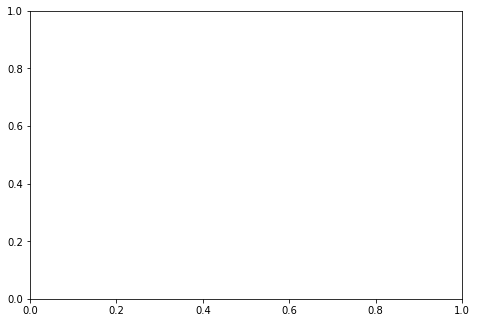

In [428]:
fig

`-` (0,1.2) 자리에 크기 (가로 = 1, 세로= 1) 크기의 그림 넣음

In [429]:
fig.add_axes([0,1.2,1,1])

<Axes:>

In [430]:
fig.axes # 2개의 엑시즈 나옴

[<Axes:>, <Axes:>]

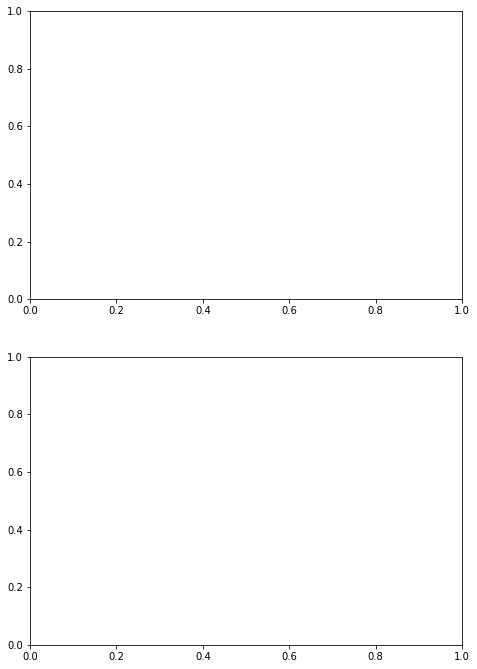

In [431]:
fig

`-` (0.5,0.5) 자리에 (가로=1, 세로=1) 크기의 그림추가 

In [432]:
fig.add_axes([0.5,0.5,1,1])

<Axes:>

In [433]:
fig.axes # 3개의 축

[<Axes:>, <Axes:>, <Axes:>]

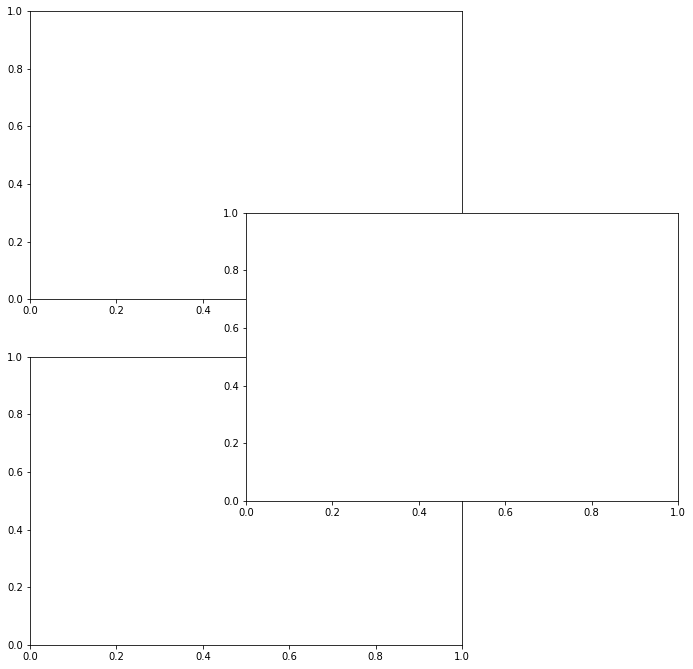

In [434]:
fig

`-` fig의 세번째 엑시즈에 접근

In [435]:
a3 = fig.axes[2] # 이것역시 오브젝트임
a3

<Axes:>

`-` 액시즈의 메소드중에서 plot이 있음 -> 이것으로 그림을 그림 

In [436]:
a3.plot([1,2,3],[4,5,3],'--r')

`-` fig에 그림 반영

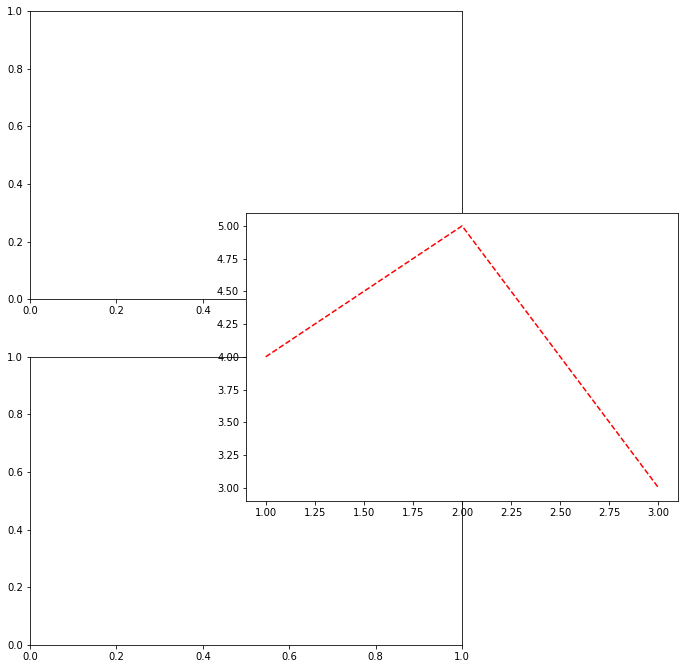

In [437]:
fig

`-` 다시 세번째 축에 접근 (이번엔 a3말고 바로 접근)

In [438]:
fig.axes[2].plot([1,2,3],[4,5,3],'.r')

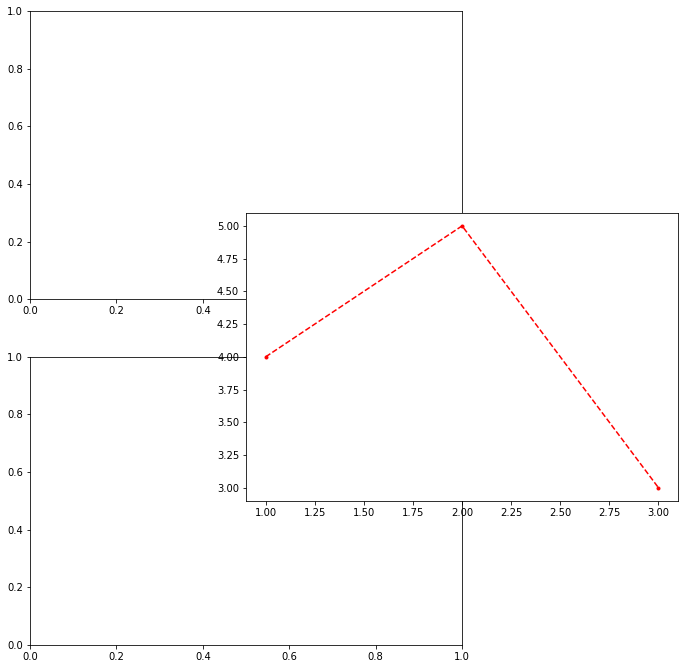

In [439]:
fig

`-` 처음만든 축에 접근하여 새로운 그림 그림 

In [440]:
fig.axes[0].plot([1,2,3],[5,4,3],':o')

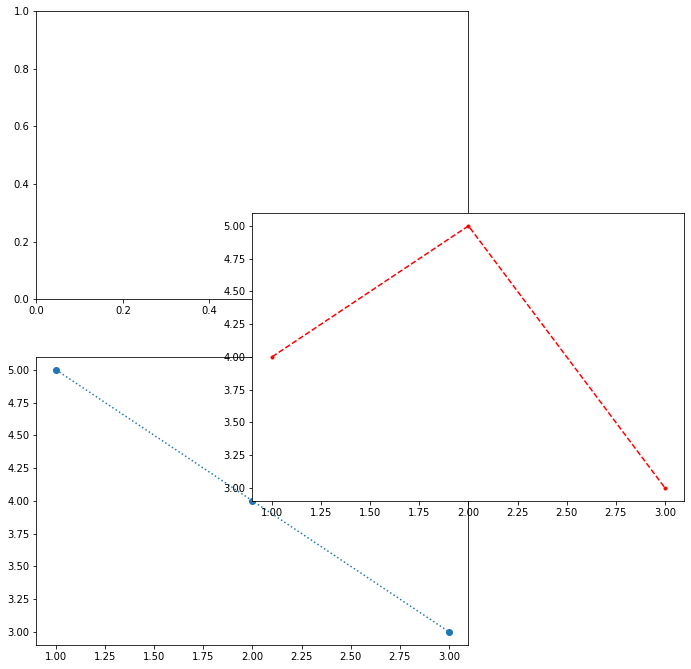

In [441]:
fig

`-` 클래스에 대한 이해가 없다면 이러한 코드를 해석하는건 불가능 